In [ ]:
import pandas as pd

# Load the training data
df_train = pd.read_csv('/content/upload.csv')

print('First 5 rows of the training data (upload.csv):')
display(df_train.head())

First 5 rows of the training data (upload.csv):


,Id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Separate features (X) and target (y)
X_train = df_train_aligned.drop('classification', axis=1)
y_train = df_train_aligned['classification'].astype(int) # Ensure y_train is integer type
X_test = df_test_aligned.drop('classification', axis=1)
y_test = df_test_aligned['classification'].astype(int)   # Ensure y_test is integer type

# Identify categorical and numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Preprocess data once for all models (especially for XGBoost and DNN)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Dictionary to store model results
results = {}

# --- Train and Evaluate Models ---

# 1. Support Vector Machine (SVM)
print("Training SVM...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)
results['SVM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_svm, zero_division=0)
}

# 2. K-Nearest Neighbors (KNN)
print("Training KNN...")
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)
results['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_knn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_knn, zero_division=0)
}

# 3. Decision Tree (DT)
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dt, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dt, zero_division=0)
}

# 4. Random Forest (RF)
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rf, zero_division=0)
}

# 5. AdaBoost
print("Training AdaBoost...")
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_processed, y_train)
y_pred_ada = ada_model.predict(X_test_processed)
results['AdaBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ada),
    'Precision': precision_score(y_test, y_pred_ada, zero_division=0),
    'Recall': recall_score(y_test, y_pred_ada, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ada, zero_division=0)
}

# 6. XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)
results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_xgb, zero_division=0)
}

# 7. Deep Neural Network (DNN)
print("Training DNN...")
input_shape = X_train_processed.shape[1]

dnn_model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

dnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

dnn_model.fit(X_train_processed, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.2)

y_pred_prob_dnn = dnn_model.predict(X_test_processed)
y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)
results['DNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dnn),
    'Precision': precision_score(y_test, y_pred_dnn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dnn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dnn, zero_division=0)
}

# Display results
results_df = pd.DataFrame(results).T
print("\n--- Model Performance Comparison ---")
display(results_df)

Training SVM...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training AdaBoost...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:54:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training DNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
SVM,1.0,1.0,1.0,1.0
KNN,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0
AdaBoost,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0
DNN,1.0,1.0,1.0,1.0


In [ ]:
# Define columns that should be numeric but are currently 'object' or have inconsistent values
numeric_cols_to_convert = ['wc']

# --- Handle 'wc' column specifically for problematic values ---
# First, check unique values for problematic entries
print('\n--- df_train_aligned wc unique values BEFORE specific cleaning ---')
if 'wc' in df_train_aligned.columns:
    print(df_train_aligned['wc'].unique())
print('\n--- df_test_aligned wc unique values BEFORE specific cleaning ---')
if 'wc' in df_test_aligned.columns:
    print(df_test_aligned['wc'].unique())

# Replace common problematic strings before numeric conversion
# This often includes whitespace, '?', or other non-numeric characters
import numpy as np # Import numpy for np.nan

for col in numeric_cols_to_convert:
    if col in df_train_aligned.columns:
        # Chain operations to ensure type conversion sticks
        df_train_aligned.loc[:, col] = pd.to_numeric(df_train_aligned[col].astype(str).str.strip().str.lower().replace({'	?': np.nan, '?': np.nan}), errors='coerce').astype(float)
        print(f"DEBUG_TRAIN: df_train_aligned['{col}'] dtype immediately after conversion: {df_train_aligned[col].dtype}")
    if col in df_test_aligned.columns:
        df_test_aligned.loc[:, col] = pd.to_numeric(df_test_aligned[col].astype(str).str.strip().str.lower().replace({'	?': np.nan, '?': np.nan}), errors='coerce').astype(float)
        print(f"DEBUG_TEST: df_test_aligned['{col}'] dtype immediately after conversion: {df_test_aligned[col].dtype}")

# Debug: Check dtype of 'wc' after numeric conversion attempt (original line kept for context)
print(f"\ndf_train_aligned['wc'] dtype after numeric conversion attempt: {df_train_aligned['wc'].dtype}")
print(f"df_test_aligned['wc'] dtype after numeric conversion attempt: {df_test_aligned['wc'].dtype}")

# Separate list for categorical columns *excluding* 'classification' (to be handled specifically) and 'wc' (already handled)
categorical_cols_for_general_cleaning = [col for col in df_train_aligned.columns
                                         if df_train_aligned[col].dtype == 'object'
                                         and col != 'classification'
                                         and col not in numeric_cols_to_convert]

# Strip whitespace and convert to lowercase for general categorical columns
for col in categorical_cols_for_general_cleaning:
    df_train_aligned.loc[:, col] = df_train_aligned[col].astype(str).str.strip().str.lower()
    if col in df_test_aligned.columns:
        df_test_aligned.loc[:, col] = df_test_aligned[col].astype(str).str.strip().str.lower()


# --- Handle 'classification' column specifically ---
# Ensure it's treated as string first, then strip and lower.
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = df_train_aligned['classification'].astype(str).str.strip().str.lower()
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = df_test_aligned['classification'].astype(str).str.strip().str.lower()

# Debug: Print unique values before classification replacement
print('\n--- df_train_aligned classification unique values BEFORE specific replacement ---')
if 'classification' in df_train_aligned.columns:
    print(df_train_aligned['classification'].unique())
print('\n--- df_test_aligned classification unique values BEFORE specific replacement ---')
if 'classification' in df_test_aligned.columns:
    print(df_test_aligned['classification'].unique())

# Now, clean 'classification' column in both dataframes with standardized string values
# Adjusted replacements based on observed unique values being '1' and '0' as strings.
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = df_train_aligned['classification'].replace({'ckd': 1.0, 'notckd': 0.0, '1': 1.0, '0': 0.0})
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = df_test_aligned['classification'].replace({'(abnormal)1': 1.0, '(normal)0': 0.0, '1': 1.0, '0': 0.0})

# Finally, convert the classification column to numeric (float to accommodate NaNs)
# Then convert to int, as it's a classification target
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = pd.to_numeric(df_train_aligned['classification'], errors='coerce').astype(int)
    print(f"DEBUG_TRAIN: df_train_aligned['classification'] dtype immediately after conversion: {df_train_aligned['classification'].dtype}")
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = pd.to_numeric(df_test_aligned['classification'], errors='coerce').astype(int)
    print(f"DEBUG_TEST: df_test_aligned['classification'] dtype immediately after conversion: {df_test_aligned['classification'].dtype}")


print('--- df_train_aligned Info After Cleaning ---')
df_train_aligned.info()
print('\n--- df_test_aligned Info After Cleaning ---')
df_test_aligned.info()

print('\nFirst 5 rows of df_train_aligned after cleaning:')
display(df_train_aligned.head())

print('\nFirst 5 rows of df_test_aligned after cleaning:')
display(df_test_aligned.head())


--- df_train_aligned wc unique values BEFORE specific cleaning ---
[7800.0 6000.0 7500.0 6700.0 7300.0 nan 6900.0 9600.0 12100.0 4500.0
 12200.0 11000.0 3800.0 11400.0 5300.0 9200.0 6200.0 8300.0 8400.0 10300.0
 9800.0 9100.0 7900.0 6400.0 8600.0 18900.0 21600.0 4300.0 8500.0 11300.0
 7200.0 7700.0 14600.0 6300.0 7100.0 11800.0 9400.0 5500.0 5800.0 13200.0
 12500.0 5600.0 7000.0 11900.0 10400.0 10700.0 12700.0 6800.0 6500.0
 13600.0 10200.0 9000.0 14900.0 8200.0 15200.0 5000.0 16300.0 12400.0
 10500.0 4200.0 4700.0 10900.0 8100.0 9500.0 2200.0 12800.0 11200.0
 19100.0 12300.0 16700.0 2600.0 26400.0 8800.0 7400.0 4900.0 8000.0
 12000.0 15700.0 4100.0 5700.0 11500.0 5400.0 10800.0 9900.0 5200.0 5900.0
 9300.0 9700.0 5100.0 6600.0]

--- df_test_aligned wc unique values BEFORE specific cleaning ---
[7800.0 6000.0 7500.0 6600.0 7200.0 6800.0]
DEBUG_TRAIN: df_train_aligned['wc'] dtype immediately after conversion: object
DEBUG_TEST: df_test_aligned['wc'] dtype immediately after conversion: 

/tmp/ipykernel_7845/2053439701.py:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train_aligned.loc[:, 'classification'] = df_train_aligned['classification'].replace({'ckd': 1.0, 'notckd': 0.0, '1': 1.0, '0': 0.0})
/tmp/ipykernel_7845/2053439701.py:63: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test_aligned.loc[:, 'classification'] = df_test_aligned['classification'].replace({'(abnormal)1': 1.0, '(normal)0': 0.0, '1': 1.0, '0': 0.0})


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,nan,yes,yes,NaN,no,1.2,80.0,normal,0.0,no,36.0,48.0,7800.0,121.0,notpresent,1.0,1
1,no,notpresent,nan,no,no,NaN,no,0.8,50.0,normal,0.0,no,18.0,7.0,6000.0,NaN,notpresent,4.0,1
2,yes,notpresent,normal,no,yes,NaN,no,1.8,80.0,normal,3.0,no,53.0,62.0,7500.0,423.0,notpresent,2.0,1
3,yes,notpresent,normal,yes,no,2.5,yes,3.8,70.0,abnormal,0.0,no,56.0,48.0,6700.0,117.0,present,4.0,1
4,no,notpresent,normal,no,no,NaN,no,1.4,80.0,normal,0.0,no,26.0,51.0,7300.0,106.0,notpresent,2.0,1



First 5 rows of df_test_aligned after cleaning:


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,normal,yes,yes,4.627244,no,1.2,80,normal,0,no,36,48,7800.0,121.000000,notpresent,1,1
1,no,notpresent,normal,no,no,4.627244,no,0.8,50,normal,0,no,18,7,6000.0,148.036517,notpresent,4,1
2,yes,notpresent,normal,no,yes,4.627244,no,1.8,80,normal,3,no,53,62,7500.0,423.000000,notpresent,2,1
3,no,notpresent,normal,no,no,4.400000,no,0.6,80,normal,0,no,26,12,6600.0,100.000000,notpresent,0,0
4,no,notpresent,normal,no,no,4.900000,no,1.0,60,normal,0,no,50,17,7200.0,114.000000,notpresent,0,0


In [ ]:
import pandas as pd
import numpy as np

# These columns should already be converted to numeric in previous steps (8f73f304)
# This cell is now primarily for verification if needed, or for any further refinements.

# Re-attempt conversion for 'wc' to ensure it's numeric
if 'wc' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'wc'] = pd.to_numeric(df_train_aligned['wc'], errors='coerce').astype(float)
if 'wc' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'wc'] = pd.to_numeric(df_test_aligned['wc'], errors='coerce').astype(float)

# Re-attempt conversion for 'classification' to ensure it's numeric
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = pd.to_numeric(df_train_aligned['classification'], errors='coerce').astype(int)
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = pd.to_numeric(df_test_aligned['classification'], errors='coerce').astype(int)

print('--- df_train_aligned Info After Re-conversion ---')
df_train_aligned.info()
print('\n--- df_test_aligned Info After Re-conversion ---')
df_test_aligned.info()

print('\nFirst 5 rows of df_train_aligned after re-conversion:')
display(df_train_aligned.head())
print('\nFirst 5 rows of df_test_aligned after re-conversion:')
display(df_test_aligned.head())

--- df_train_aligned Info After Re-conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ane             400 non-null    object 
 1   ba              400 non-null    object 
 2   rbc             400 non-null    object 
 3   htn             400 non-null    object 
 4   dm              400 non-null    object 
 5   pot             312 non-null    float64
 6   pe              400 non-null    object 
 7   sc              383 non-null    float64
 8   bp              388 non-null    float64
 9   pc              400 non-null    object 
 10  su              351 non-null    float64
 11  cad             400 non-null    object 
 12  bu              381 non-null    float64
 13  age             391 non-null    float64
 14  wc              294 non-null    object 
 15  bgr             356 non-null    float64
 16  pcc             400 non-null  

,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,nan,yes,yes,NaN,no,1.2,80.0,normal,0.0,no,36.0,48.0,7800.0,121.0,notpresent,1.0,1
1,no,notpresent,nan,no,no,NaN,no,0.8,50.0,normal,0.0,no,18.0,7.0,6000.0,NaN,notpresent,4.0,1
2,yes,notpresent,normal,no,yes,NaN,no,1.8,80.0,normal,3.0,no,53.0,62.0,7500.0,423.0,notpresent,2.0,1
3,yes,notpresent,normal,yes,no,2.5,yes,3.8,70.0,abnormal,0.0,no,56.0,48.0,6700.0,117.0,present,4.0,1
4,no,notpresent,normal,no,no,NaN,no,1.4,80.0,normal,0.0,no,26.0,51.0,7300.0,106.0,notpresent,2.0,1



First 5 rows of df_test_aligned after re-conversion:


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,normal,yes,yes,4.627244,no,1.2,80,normal,0,no,36,48,7800.0,121.000000,notpresent,1,1
1,no,notpresent,normal,no,no,4.627244,no,0.8,50,normal,0,no,18,7,6000.0,148.036517,notpresent,4,1
2,yes,notpresent,normal,no,yes,4.627244,no,1.8,80,normal,3,no,53,62,7500.0,423.000000,notpresent,2,1
3,no,notpresent,normal,no,no,4.400000,no,0.6,80,normal,0,no,26,12,6600.0,100.000000,notpresent,0,0
4,no,notpresent,normal,no,no,4.900000,no,1.0,60,normal,0,no,50,17,7200.0,114.000000,notpresent,0,0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Separate features (X) and target (y)
X_train = df_train_aligned.drop('classification', axis=1)
y_train = df_train_aligned['classification'].astype(int) # Ensure y_train is integer type
X_test = df_test_aligned.drop('classification', axis=1)
y_test = df_test_aligned['classification'].astype(int)   # Ensure y_test is integer type

# Identify categorical and numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Preprocess data once for all models (especially for XGBoost and DNN)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Dictionary to store model results
results = {}

# --- Train and Evaluate Models ---

# 1. Support Vector Machine (SVM)
print("Training SVM...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)
results['SVM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_svm, zero_division=0)
}

# 2. K-Nearest Neighbors (KNN)
print("Training KNN...")
kNN_model = KNeighborsClassifier()
kNN_model.fit(X_train_processed, y_train)
y_pred_knn = kNN_model.predict(X_test_processed)
results['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_knn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_knn, zero_division=0)
}

# 3. Decision Tree (DT)
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dt, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dt, zero_division=0)
}

# 4. Random Forest (RF)
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rf, zero_division=0)
}

# 5. AdaBoost
print("Training AdaBoost...")
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_processed, y_train)
y_pred_ada = ada_model.predict(X_test_processed)
results['AdaBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ada),
    'Precision': precision_score(y_test, y_pred_ada, zero_division=0),
    'Recall': recall_score(y_test, y_pred_ada, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ada, zero_division=0)
}

# 6. XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)
results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_xgb, zero_division=0)
}

# 7. Deep Neural Network (DNN)
print("Training DNN...")
input_shape = X_train_processed.shape[1]

dnn_model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

dnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

dnn_model.fit(X_train_processed, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.2)

y_pred_prob_dnn = dnn_model.predict(X_test_processed)
y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)
results['DNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dnn),
    'Precision': precision_score(y_test, y_pred_dnn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dnn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dnn, zero_division=0)
}

# Display results
results_df = pd.DataFrame(results).T
print("\n--- Model Performance Comparison ---")
display(results_df)

Training SVM...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training AdaBoost...
Training XGBoost...
Training DNN...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:54:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
SVM,1.0,1.0,1.0,1.0
KNN,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0
AdaBoost,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0
DNN,1.0,1.0,1.0,1.0


In [ ]:
import pandas as pd
import numpy as np

# These columns should already be converted to numeric in previous steps (8f73f304)
# This cell is now primarily for verification if needed, or for any further refinements.

# Re-attempt conversion for 'wc' to ensure it's numeric
if 'wc' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'wc'] = pd.to_numeric(df_train_aligned['wc'], errors='coerce').astype(float)
if 'wc' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'wc'] = pd.to_numeric(df_test_aligned['wc'], errors='coerce').astype(float)

# Re-attempt conversion for 'classification' to ensure it's numeric
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = pd.to_numeric(df_train_aligned['classification'], errors='coerce').astype(int)
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = pd.to_numeric(df_test_aligned['classification'], errors='coerce').astype(int)

print('--- df_train_aligned Info After Re-conversion ---')
df_train_aligned.info()
print('\n--- df_test_aligned Info After Re-conversion ---')
df_test_aligned.info()

print('\nFirst 5 rows of df_train_aligned after re-conversion:')
display(df_train_aligned.head())
print('\nFirst 5 rows of df_test_aligned after re-conversion:')
display(df_test_aligned.head())

--- df_train_aligned Info After Re-conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ane             400 non-null    object 
 1   ba              400 non-null    object 
 2   rbc             400 non-null    object 
 3   htn             400 non-null    object 
 4   dm              400 non-null    object 
 5   pot             312 non-null    float64
 6   pe              400 non-null    object 
 7   sc              383 non-null    float64
 8   bp              388 non-null    float64
 9   pc              400 non-null    object 
 10  su              351 non-null    float64
 11  cad             400 non-null    object 
 12  bu              381 non-null    float64
 13  age             391 non-null    float64
 14  wc              294 non-null    object 
 15  bgr             356 non-null    float64
 16  pcc             400 non-null  

,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,nan,yes,yes,NaN,no,1.2,80.0,normal,0.0,no,36.0,48.0,7800.0,121.0,notpresent,1.0,1
1,no,notpresent,nan,no,no,NaN,no,0.8,50.0,normal,0.0,no,18.0,7.0,6000.0,NaN,notpresent,4.0,1
2,yes,notpresent,normal,no,yes,NaN,no,1.8,80.0,normal,3.0,no,53.0,62.0,7500.0,423.0,notpresent,2.0,1
3,yes,notpresent,normal,yes,no,2.5,yes,3.8,70.0,abnormal,0.0,no,56.0,48.0,6700.0,117.0,present,4.0,1
4,no,notpresent,normal,no,no,NaN,no,1.4,80.0,normal,0.0,no,26.0,51.0,7300.0,106.0,notpresent,2.0,1



First 5 rows of df_test_aligned after re-conversion:


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,normal,yes,yes,4.627244,no,1.2,80,normal,0,no,36,48,7800.0,121.000000,notpresent,1,1
1,no,notpresent,normal,no,no,4.627244,no,0.8,50,normal,0,no,18,7,6000.0,148.036517,notpresent,4,1
2,yes,notpresent,normal,no,yes,4.627244,no,1.8,80,normal,3,no,53,62,7500.0,423.000000,notpresent,2,1
3,no,notpresent,normal,no,no,4.400000,no,0.6,80,normal,0,no,26,12,6600.0,100.000000,notpresent,0,0
4,no,notpresent,normal,no,no,4.900000,no,1.0,60,normal,0,no,50,17,7200.0,114.000000,notpresent,0,0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Separate features (X) and target (y)
X_train = df_train_aligned.drop('classification', axis=1)
y_train = df_train_aligned['classification'].astype(int) # Ensure y_train is integer type
X_test = df_test_aligned.drop('classification', axis=1)
y_test = df_test_aligned['classification'].astype(int)   # Ensure y_test is integer type

# Identify categorical and numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Preprocess data once for all models (especially for XGBoost and DNN)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Dictionary to store model results
results = {}

# --- Train and Evaluate Models ---

# 1. Support Vector Machine (SVM)
print("Training SVM...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)
results['SVM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_svm, zero_division=0)
}

# 2. K-Nearest Neighbors (KNN)
print("Training KNN...")
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)
results['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_knn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_knn, zero_division=0)
}

# 3. Decision Tree (DT)
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dt, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dt, zero_division=0)
}

# 4. Random Forest (RF)
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rf, zero_division=0)
}

# 5. AdaBoost
print("Training AdaBoost...")
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_processed, y_train)
y_pred_ada = ada_model.predict(X_test_processed)
results['AdaBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ada),
    'Precision': precision_score(y_test, y_pred_ada, zero_division=0),
    'Recall': recall_score(y_test, y_pred_ada, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ada, zero_division=0)
}

# 6. XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)
results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_xgb, zero_division=0)
}

# 7. Deep Neural Network (DNN)
print("Training DNN...")
input_shape = X_train_processed.shape[1]

dnn_model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

dnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

dnn_model.fit(X_train_processed, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.2)

y_pred_prob_dnn = dnn_model.predict(X_test_processed)
y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)
results['DNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dnn),
    'Precision': precision_score(y_test, y_pred_dnn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dnn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dnn, zero_division=0)
}

# Display results
results_df = pd.DataFrame(results).T
print("\n--- Model Performance Comparison ---")
display(results_df)

Training SVM...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training AdaBoost...
Training XGBoost...
Training DNN...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:54:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
SVM,1.0,1.0,1.0,1.0
KNN,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0
AdaBoost,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0
DNN,1.0,1.0,1.0,1.0


In [ ]:
# Create a DataFrame to compare actual vs. predicted values
predictions_df = pd.DataFrame({
    'Actual_Classification': y_test,
    'SVM_Prediction': y_pred_svm,
    'KNN_Prediction': y_pred_knn,
    'DecisionTree_Prediction': y_pred_dt,
    'RandomForest_Prediction': y_pred_rf,
    'AdaBoost_Prediction': y_pred_ada,
    'XGBoost_Prediction': y_pred_xgb,
    'DNN_Prediction': y_pred_dnn.flatten() # Flatten DNN predictions if they are 2D
})

print("\n--- Actual vs. Predicted Classification for Test Set ---")
display(predictions_df)


--- Actual vs. Predicted Classification for Test Set ---


,Actual_Classification,SVM_Prediction,KNN_Prediction,DecisionTree_Prediction,RandomForest_Prediction,AdaBoost_Prediction,XGBoost_Prediction,DNN_Prediction
0,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0


In [ ]:
import pandas as pd
import numpy as np

# These columns should already be converted to numeric in previous steps (8f73f304)
# This cell is now primarily for verification if needed, or for any further refinements.

# Re-attempt conversion for 'wc' to ensure it's numeric
if 'wc' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'wc'] = pd.to_numeric(df_train_aligned['wc'], errors='coerce').astype(float)
if 'wc' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'wc'] = pd.to_numeric(df_test_aligned['wc'], errors='coerce').astype(float)

# Re-attempt conversion for 'classification' to ensure it's numeric
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = pd.to_numeric(df_train_aligned['classification'], errors='coerce').astype(int)
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = pd.to_numeric(df_test_aligned['classification'], errors='coerce').astype(int)

print('--- df_train_aligned Info After Re-conversion ---')
df_train_aligned.info()
print('\n--- df_test_aligned Info After Re-conversion ---')
df_test_aligned.info()

print('\nFirst 5 rows of df_train_aligned after re-conversion:')
display(df_train_aligned.head())
print('\nFirst 5 rows of df_test_aligned after re-conversion:')
display(df_test_aligned.head())

--- df_train_aligned Info After Re-conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ane             400 non-null    object 
 1   ba              400 non-null    object 
 2   rbc             400 non-null    object 
 3   htn             400 non-null    object 
 4   dm              400 non-null    object 
 5   pot             312 non-null    float64
 6   pe              400 non-null    object 
 7   sc              383 non-null    float64
 8   bp              388 non-null    float64
 9   pc              400 non-null    object 
 10  su              351 non-null    float64
 11  cad             400 non-null    object 
 12  bu              381 non-null    float64
 13  age             391 non-null    float64
 14  wc              294 non-null    object 
 15  bgr             356 non-null    float64
 16  pcc             400 non-null  

,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,nan,yes,yes,NaN,no,1.2,80.0,normal,0.0,no,36.0,48.0,7800.0,121.0,notpresent,1.0,1
1,no,notpresent,nan,no,no,NaN,no,0.8,50.0,normal,0.0,no,18.0,7.0,6000.0,NaN,notpresent,4.0,1
2,yes,notpresent,normal,no,yes,NaN,no,1.8,80.0,normal,3.0,no,53.0,62.0,7500.0,423.0,notpresent,2.0,1
3,yes,notpresent,normal,yes,no,2.5,yes,3.8,70.0,abnormal,0.0,no,56.0,48.0,6700.0,117.0,present,4.0,1
4,no,notpresent,normal,no,no,NaN,no,1.4,80.0,normal,0.0,no,26.0,51.0,7300.0,106.0,notpresent,2.0,1



First 5 rows of df_test_aligned after re-conversion:


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,normal,yes,yes,4.627244,no,1.2,80,normal,0,no,36,48,7800.0,121.000000,notpresent,1,1
1,no,notpresent,normal,no,no,4.627244,no,0.8,50,normal,0,no,18,7,6000.0,148.036517,notpresent,4,1
2,yes,notpresent,normal,no,yes,4.627244,no,1.8,80,normal,3,no,53,62,7500.0,423.000000,notpresent,2,1
3,no,notpresent,normal,no,no,4.400000,no,0.6,80,normal,0,no,26,12,6600.0,100.000000,notpresent,0,0
4,no,notpresent,normal,no,no,4.900000,no,1.0,60,normal,0,no,50,17,7200.0,114.000000,notpresent,0,0


In [ ]:
# Install xgboost if not already present
%pip install xgboost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Separate features (X) and target (y)
X_train = df_train_aligned.drop('classification', axis=1)
y_train = df_train_aligned['classification'].astype(int) # Ensure y_train is integer type
X_test = df_test_aligned.drop('classification', axis=1)
y_test = df_test_aligned['classification'].astype(int)   # Ensure y_test is integer type

# Identify categorical and numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Preprocess data once for all models (especially for XGBoost and DNN)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Dictionary to store model results
results = {}

# --- Train and Evaluate Models ---

# 1. Support Vector Machine (SVM)
print("Training SVM...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)
results['SVM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_svm, zero_division=0)
}

# 2. K-Nearest Neighbors (KNN)
print("Training KNN...")
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)
results['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_knn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_knn, zero_division=0)
}

# 3. Decision Tree (DT)
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dt, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dt, zero_division=0)
}

# 4. Random Forest (RF)
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rf, zero_division=0)
}

# 5. AdaBoost
print("Training AdaBoost...")
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_processed, y_train)
y_pred_ada = ada_model.predict(X_test_processed)
results['AdaBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ada),
    'Precision': precision_score(y_test, y_pred_ada, zero_division=0),
    'Recall': recall_score(y_test, y_pred_ada, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ada, zero_division=0)
}

# 6. XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)
results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_xgb, zero_division=0)
}

# 7. Deep Neural Network (DNN)
print("Training DNN...")
input_shape = X_train_processed.shape[1]

dnn_model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

dnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

dnn_model.fit(X_train_processed, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.2)

y_pred_prob_dnn = dnn_model.predict(X_test_processed)
y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)
results['DNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dnn),
    'Precision': precision_score(y_test, y_pred_dnn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dnn, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dnn, zero_division=0)
}

# Display results
results_df = pd.DataFrame(results).T
print("\n--- Model Performance Comparison ---")
display(results_df)

Training SVM...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training AdaBoost...
Training XGBoost...
Training DNN...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:47:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
SVM,1.0,1.0,1.0,1.0
KNN,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0
AdaBoost,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0
DNN,1.0,1.0,1.0,1.0


### Step 1: Data Inspection
Let's start by inspecting the training data (`df_train`) to understand its structure, identify data types, and check for missing values.

In [ ]:
print('--- df_train Info ---')
df_train.info()

print('\n--- df_train Missing Values ---')
display(df_train.isnull().sum())

--- df_train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc           

,0
Id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


Now, let's do the same for the testing data (`df_test`).

In [ ]:
print('--- df_test Info ---')
df_test.info()

print('\n--- df_test Missing Values ---')
display(df_test.isnull().sum())

--- df_test Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      6 non-null      int64  
 1   blood_pressure           6 non-null      int64  
 2   albumin                  6 non-null      int64  
 3   sugar                    6 non-null      int64  
 4   red_blood_cells          6 non-null      object 
 5   pus_cell                 6 non-null      object 
 6   pus_cell_clumps          6 non-null      object 
 7   bacteria                 6 non-null      object 
 8   blood_glucose_random     6 non-null      float64
 9   blood_urea               6 non-null      int64  
 10  serum_creatinine         6 non-null      float64
 11  potassium                6 non-null      float64
 12  white_blood_cell_count   6 non-null      int64  
 13  hypertension             6 non-null      object 
 14  diabetes_

,0
age,0
blood_pressure,0
albumin,0
sugar,0
red_blood_cells,0
pus_cell,0
pus_cell_clumps,0
bacteria,0
blood_glucose_random,0
blood_urea,0


After inspecting the data, we'll proceed with data cleaning, preprocessing, and then the model benchmarking.

### Step 3: Data Cleaning and Preprocessing - Value and Type Alignment

Now that column names are aligned, let's clean the values within the columns, standardize the target variable, and convert data types.

In [ ]:
# Define columns that should be numeric but are currently 'object' or have inconsistent values
numeric_cols_to_convert = ['wc']

# --- Handle 'wc' column specifically for problematic values ---
# First, check unique values for problematic entries
print('\n--- df_train_aligned wc unique values BEFORE specific cleaning ---')
if 'wc' in df_train_aligned.columns:
    print(df_train_aligned['wc'].unique())
print('\n--- df_test_aligned wc unique values BEFORE specific cleaning ---')
if 'wc' in df_test_aligned.columns:
    print(df_test_aligned['wc'].unique())

# Replace common problematic strings before numeric conversion
# This often includes whitespace, '?', or other non-numeric characters
import numpy as np # Import numpy for np.nan

for col in numeric_cols_to_convert:
    if col in df_train_aligned.columns:
        # Chain operations to ensure type conversion sticks
        df_train_aligned.loc[:, col] = pd.to_numeric(df_train_aligned[col].astype(str).str.strip().str.lower().replace({'	?': np.nan, '?': np.nan}), errors='coerce').astype(float)
        print(f"DEBUG_TRAIN: df_train_aligned['{col}'] dtype immediately after conversion: {df_train_aligned[col].dtype}")
    if col in df_test_aligned.columns:
        df_test_aligned.loc[:, col] = pd.to_numeric(df_test_aligned[col].astype(str).str.strip().str.lower().replace({'	?': np.nan, '?': np.nan}), errors='coerce').astype(float)
        print(f"DEBUG_TEST: df_test_aligned['{col}'] dtype immediately after conversion: {df_test_aligned[col].dtype}")

# Debug: Check dtype of 'wc' after numeric conversion attempt (original line kept for context)
print(f"\ndf_train_aligned['wc'] dtype after numeric conversion attempt: {df_train_aligned['wc'].dtype}")
print(f"df_test_aligned['wc'] dtype after numeric conversion attempt: {df_test_aligned['wc'].dtype}")

# Separate list for categorical columns *excluding* 'classification' (to be handled specifically) and 'wc' (already handled)
categorical_cols_for_general_cleaning = [col for col in df_train_aligned.columns
                                         if df_train_aligned[col].dtype == 'object'
                                         and col != 'classification'
                                         and col not in numeric_cols_to_convert]

# Strip whitespace and convert to lowercase for general categorical columns
for col in categorical_cols_for_general_cleaning:
    df_train_aligned.loc[:, col] = df_train_aligned[col].astype(str).str.strip().str.lower()
    if col in df_test_aligned.columns:
        df_test_aligned.loc[:, col] = df_test_aligned[col].astype(str).str.strip().str.lower()


# --- Handle 'classification' column specifically ---
# Ensure it's treated as string first, then strip and lower.
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = df_train_aligned['classification'].astype(str).str.strip().str.lower()
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = df_test_aligned['classification'].astype(str).str.strip().str.lower()

# Debug: Print unique values before classification replacement
print('\n--- df_train_aligned classification unique values BEFORE specific replacement ---')
if 'classification' in df_train_aligned.columns:
    print(df_train_aligned['classification'].unique())
print('\n--- df_test_aligned classification unique values BEFORE specific replacement ---')
if 'classification' in df_test_aligned.columns:
    print(df_test_aligned['classification'].unique())

# Now, clean 'classification' column in both dataframes with standardized string values
# Adjusted replacements based on observed unique values being '1' and '0' as strings.
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = df_train_aligned['classification'].replace({'ckd': 1.0, 'notckd': 0.0, '1': 1.0, '0': 0.0})
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = df_test_aligned['classification'].replace({'(abnormal)1': 1.0, '(normal)0': 0.0, '1': 1.0, '0': 0.0})

# Finally, convert the classification column to numeric (float to accommodate NaNs)
# Then convert to int, as it's a classification target
if 'classification' in df_train_aligned.columns:
    df_train_aligned.loc[:, 'classification'] = pd.to_numeric(df_train_aligned['classification'], errors='coerce').astype(int)
    print(f"DEBUG_TRAIN: df_train_aligned['classification'] dtype immediately after conversion: {df_train_aligned['classification'].dtype}")
if 'classification' in df_test_aligned.columns:
    df_test_aligned.loc[:, 'classification'] = pd.to_numeric(df_test_aligned['classification'], errors='coerce').astype(int)
    print(f"DEBUG_TEST: df_test_aligned['classification'] dtype immediately after conversion: {df_test_aligned['classification'].dtype}")


print('--- df_train_aligned Info After Cleaning ---')
df_train_aligned.info()
print('\n--- df_test_aligned Info After Cleaning ---')
df_test_aligned.info()

print('\nFirst 5 rows of df_train_aligned after cleaning:')
display(df_train_aligned.head())

print('\nFirst 5 rows of df_test_aligned after cleaning:')
display(df_test_aligned.head())


--- df_train_aligned wc unique values BEFORE specific cleaning ---
[7800.0 6000.0 7500.0 6700.0 7300.0 nan 6900.0 9600.0 12100.0 4500.0
 12200.0 11000.0 3800.0 11400.0 5300.0 9200.0 6200.0 8300.0 8400.0 10300.0
 9800.0 9100.0 7900.0 6400.0 8600.0 18900.0 21600.0 4300.0 8500.0 11300.0
 7200.0 7700.0 14600.0 6300.0 7100.0 11800.0 9400.0 5500.0 5800.0 13200.0
 12500.0 5600.0 7000.0 11900.0 10400.0 10700.0 12700.0 6800.0 6500.0
 13600.0 10200.0 9000.0 14900.0 8200.0 15200.0 5000.0 16300.0 12400.0
 10500.0 4200.0 4700.0 10900.0 8100.0 9500.0 2200.0 12800.0 11200.0
 19100.0 12300.0 16700.0 2600.0 26400.0 8800.0 7400.0 4900.0 8000.0
 12000.0 15700.0 4100.0 5700.0 11500.0 5400.0 10800.0 9900.0 5200.0 5900.0
 9300.0 9700.0 5100.0 6600.0]

--- df_test_aligned wc unique values BEFORE specific cleaning ---
[7800.0 6000.0 7500.0 6600.0 7200.0 6800.0]
DEBUG_TRAIN: df_train_aligned['wc'] dtype immediately after conversion: object
DEBUG_TEST: df_test_aligned['wc'] dtype immediately after conversion: 

/tmp/ipykernel_7845/2053439701.py:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train_aligned.loc[:, 'classification'] = df_train_aligned['classification'].replace({'ckd': 1.0, 'notckd': 0.0, '1': 1.0, '0': 0.0})
/tmp/ipykernel_7845/2053439701.py:63: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test_aligned.loc[:, 'classification'] = df_test_aligned['classification'].replace({'(abnormal)1': 1.0, '(normal)0': 0.0, '1': 1.0, '0': 0.0})


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,nan,yes,yes,NaN,no,1.2,80.0,normal,0.0,no,36.0,48.0,7800.0,121.0,notpresent,1.0,1
1,no,notpresent,nan,no,no,NaN,no,0.8,50.0,normal,0.0,no,18.0,7.0,6000.0,NaN,notpresent,4.0,1
2,yes,notpresent,normal,no,yes,NaN,no,1.8,80.0,normal,3.0,no,53.0,62.0,7500.0,423.0,notpresent,2.0,1
3,yes,notpresent,normal,yes,no,2.5,yes,3.8,70.0,abnormal,0.0,no,56.0,48.0,6700.0,117.0,present,4.0,1
4,no,notpresent,normal,no,no,NaN,no,1.4,80.0,normal,0.0,no,26.0,51.0,7300.0,106.0,notpresent,2.0,1



First 5 rows of df_test_aligned after cleaning:


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,normal,yes,yes,4.627244,no,1.2,80,normal,0,no,36,48,7800.0,121.000000,notpresent,1,1
1,no,notpresent,normal,no,no,4.627244,no,0.8,50,normal,0,no,18,7,6000.0,148.036517,notpresent,4,1
2,yes,notpresent,normal,no,yes,4.627244,no,1.8,80,normal,3,no,53,62,7500.0,423.000000,notpresent,2,1
3,no,notpresent,normal,no,no,4.400000,no,0.6,80,normal,0,no,26,12,6600.0,100.000000,notpresent,0,0
4,no,notpresent,normal,no,no,4.900000,no,1.0,60,normal,0,no,50,17,7200.0,114.000000,notpresent,0,0


### Step 2: Data Cleaning and Preprocessing - Initial Alignment

First, let's address the column name discrepancies between `df_train` and `df_test`.

In [ ]:
# Rename columns in df_test to match df_train where appropriate
column_mapping = {
    'blood_pressure': 'bp',
    'albumin': 'al',
    'sugar': 'su',
    'red_blood_cells': 'rbc',
    'pus_cell': 'pc',
    'pus_cell_clumps': 'pcc',
    'bacteria': 'ba',
    'blood_glucose_random': 'bgr',
    'blood_urea': 'bu',
    'serum_creatinine': 'sc',
    'potassium': 'pot',
    'white_blood_cell_count': 'wc',
    'hypertension': 'htn',
    'diabetes_mellitus': 'dm',
    'coronary_artery_disease': 'cad',
    'peda_edema': 'pe',
    'aanemia': 'ane',
    'class': 'classification' # Target variable
}

df_test = df_test.rename(columns=column_mapping)

print('df_test columns after renaming:')
print(df_test.columns.tolist())

# Drop the 'Id' column from df_train as it's not a feature and not in df_test
if 'Id' in df_train.columns:
    df_train = df_train.drop('Id', axis=1)

# Identify common columns between df_train and df_test after renaming
common_cols = list(set(df_train.columns) & set(df_test.columns))

# Ensure the target variable is included and potentially separate it later
if 'classification' in common_cols:
    common_cols.remove('classification')
    common_cols.append('classification') # Move to end or handle separately

# Filter both dataframes to only include common columns and make explicit copies
df_train_aligned = df_train[common_cols].copy()
df_test_aligned = df_test[common_cols].copy()

print('\nCommon columns selected for df_train_aligned and df_test_aligned:')
print(common_cols)

print('\ndf_train_aligned head:')
display(df_train_aligned.head())

print('\ndf_test_aligned head:')
display(df_test_aligned.head())

df_test columns after renaming:
['age', 'bp', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'pot', 'wc', 'htn', 'dm', 'cad', 'pe', 'ane', 'classification']

Common columns selected for df_train_aligned and df_test_aligned:
['ane', 'ba', 'rbc', 'htn', 'dm', 'pot', 'pe', 'sc', 'bp', 'pc', 'su', 'cad', 'bu', 'age', 'wc', 'bgr', 'pcc', 'al', 'classification']

df_train_aligned head:


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,NaN,yes,yes,NaN,no,1.2,80.0,normal,0.0,no,36.0,48.0,7800,121.0,notpresent,1.0,ckd
1,no,notpresent,NaN,no,no,NaN,no,0.8,50.0,normal,0.0,no,18.0,7.0,6000,NaN,notpresent,4.0,ckd
2,yes,notpresent,normal,no,yes,NaN,no,1.8,80.0,normal,3.0,no,53.0,62.0,7500,423.0,notpresent,2.0,ckd
3,yes,notpresent,normal,yes,no,2.5,yes,3.8,70.0,abnormal,0.0,no,56.0,48.0,6700,117.0,present,4.0,ckd
4,no,notpresent,normal,no,no,NaN,no,1.4,80.0,normal,0.0,no,26.0,51.0,7300,106.0,notpresent,2.0,ckd



df_test_aligned head:


,ane,ba,rbc,htn,dm,pot,pe,sc,bp,pc,su,cad,bu,age,wc,bgr,pcc,al,classification
0,no,notpresent,normal,yes,yes,4.627244,no,1.2,80,normal,0,no,36,48,7800,121.000000,notpresent,1,(Abnormal)1
1,no,notpresent,normal,no,no,4.627244,no,0.8,50,normal,0,no,18,7,6000,148.036517,notpresent,4,(Abnormal)1
2,yes,notpresent,normal,no,yes,4.627244,no,1.8,80,normal,3,no,53,62,7500,423.000000,notpresent,2,(Abnormal)1
3,no,notpresent,normal,no,no,4.400000,no,0.6,80,normal,0,no,26,12,6600,100.000000,notpresent,0,(normal)0
4,no,notpresent,normal,no,no,4.900000,no,1.0,60,normal,0,no,50,17,7200,114.000000,notpresent,0,(normal)0


In [ ]:
# Load the testing data
df_test = pd.read_csv('/content/test.csv')

print('\nFirst 5 rows of the testing data (test.csv):')
display(df_test.head())


First 5 rows of the testing data (test.csv):


,age,blood_pressure,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,potassium,white_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,peda_edema,aanemia,class
0,48,80,1,0,normal,normal,notpresent,notpresent,121.000000,36,1.2,4.627244,7800,yes,yes,no,no,no,(Abnormal)1
1,7,50,4,0,normal,normal,notpresent,notpresent,148.036517,18,0.8,4.627244,6000,no,no,no,no,no,(Abnormal)1
2,62,80,2,3,normal,normal,notpresent,notpresent,423.000000,53,1.8,4.627244,7500,no,yes,no,no,yes,(Abnormal)1
3,12,80,0,0,normal,normal,notpresent,notpresent,100.000000,26,0.6,4.400000,6600,no,no,no,no,no,(normal)0
4,17,60,0,0,normal,normal,notpresent,notpresent,114.000000,50,1.0,4.900000,7200,no,no,no,no,no,(normal)0


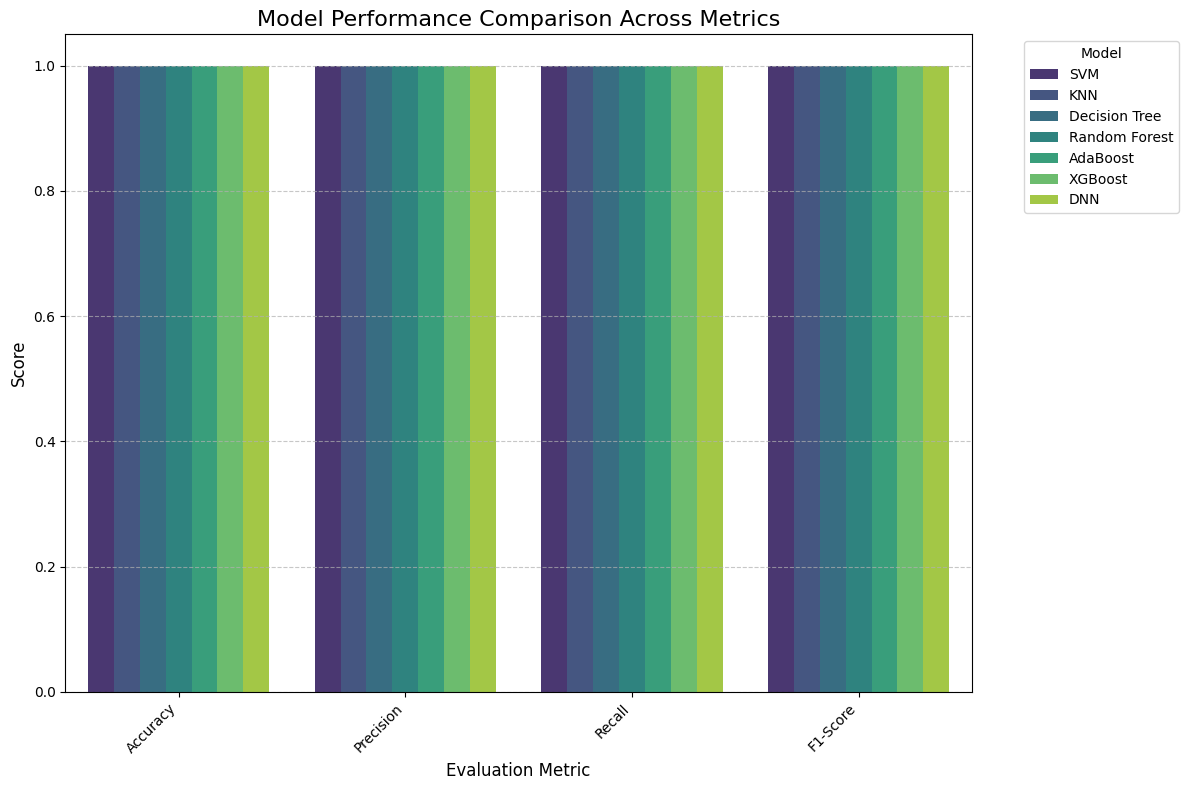

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size for better readability
plt.figure(figsize=(12, 8))

# Melt the results_df to long format for seaborn bar plot
results_melted = results_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

# Create the bar plot
sns.barplot(x='Metric', y='Score', hue='index', data=results_melted, palette='viridis')

# Add titles and labels
plt.title('Model Performance Comparison Across Metrics', fontsize=16)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1 for scores
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Re-define models for cross-validation
models_for_cv = {
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    # DNN cannot be directly used with sklearn's cross_val_score, so it will be excluded for simplicity in this general CV approach
}

# Initialize Stratified K-Fold cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print("Performing Cross-Validation...")

for model_name, model in models_for_cv.items():
    print(f"  -> Cross-validating {model_name}...")
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    # Use the preprocessed data (X_train_processed, y_train)
    for train_index, val_index in skf.split(X_train_processed, y_train):
        X_train_fold, X_val_fold = X_train_processed[train_index], X_train_processed[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_val_fold)

        accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
        precision_scores.append(precision_score(y_val_fold, y_pred_fold, zero_division=0))
        recall_scores.append(recall_score(y_val_fold, y_pred_fold, zero_division=0))
        f1_scores.append(f1_score(y_val_fold, y_pred_fold, zero_division=0))

    cv_results[model_name] = {
        'Mean Accuracy': np.mean(accuracy_scores),
        'Std Accuracy': np.std(accuracy_scores),
        'Mean Precision': np.mean(precision_scores),
        'Std Precision': np.std(precision_scores),
        'Mean Recall': np.mean(recall_scores),
        'Std Recall': np.std(recall_scores),
        'Mean F1-Score': np.mean(f1_scores),
        'Std F1-Score': np.std(f1_scores),
    }

cv_results_df = pd.DataFrame(cv_results).T
print("\n--- Cross-Validation Results ---")
display(cv_results_df)


Performing Cross-Validation...
  -> Cross-validating SVM...
  -> Cross-validating KNN...
  -> Cross-validating Decision Tree...
  -> Cross-validating Random Forest...
  -> Cross-validating AdaBoost...
  -> Cross-validating XGBoost...

--- Cross-Validation Results ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:59:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:59:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:59:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:59:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Mean Accuracy,Std Accuracy,Mean Precision,Std Precision,Mean Recall,Std Recall,Mean F1-Score,Std F1-Score
SVM,0.9825,0.012748,0.980836,0.020672,0.992,0.016000,0.986133,0.009994
KNN,0.9725,0.020000,1.000000,0.000000,0.956,0.032000,0.977231,0.016726
Decision Tree,0.9675,0.006124,0.979994,0.012406,0.968,0.009798,0.973857,0.004856
Random Forest,1.0000,0.000000,1.000000,0.000000,1.000,0.000000,1.000000,0.000000
AdaBoost,0.9850,0.018371,0.992000,0.016000,0.984,0.014967,0.987960,0.014692
XGBoost,0.9925,0.010000,1.000000,0.000000,0.988,0.016000,0.993898,0.008153


In [ ]:
from google.colab import sheets
from google.colab import auth
auth.authenticate_user()
sheet = sheets.InteractiveSheet(df=cv_results_df)

https://docs.google.com/spreadsheets/d/13Wdwhtuwk3gFmbBswwapr_E_bGxRQMTHpf3BXqMAA5M/edit#gid=0


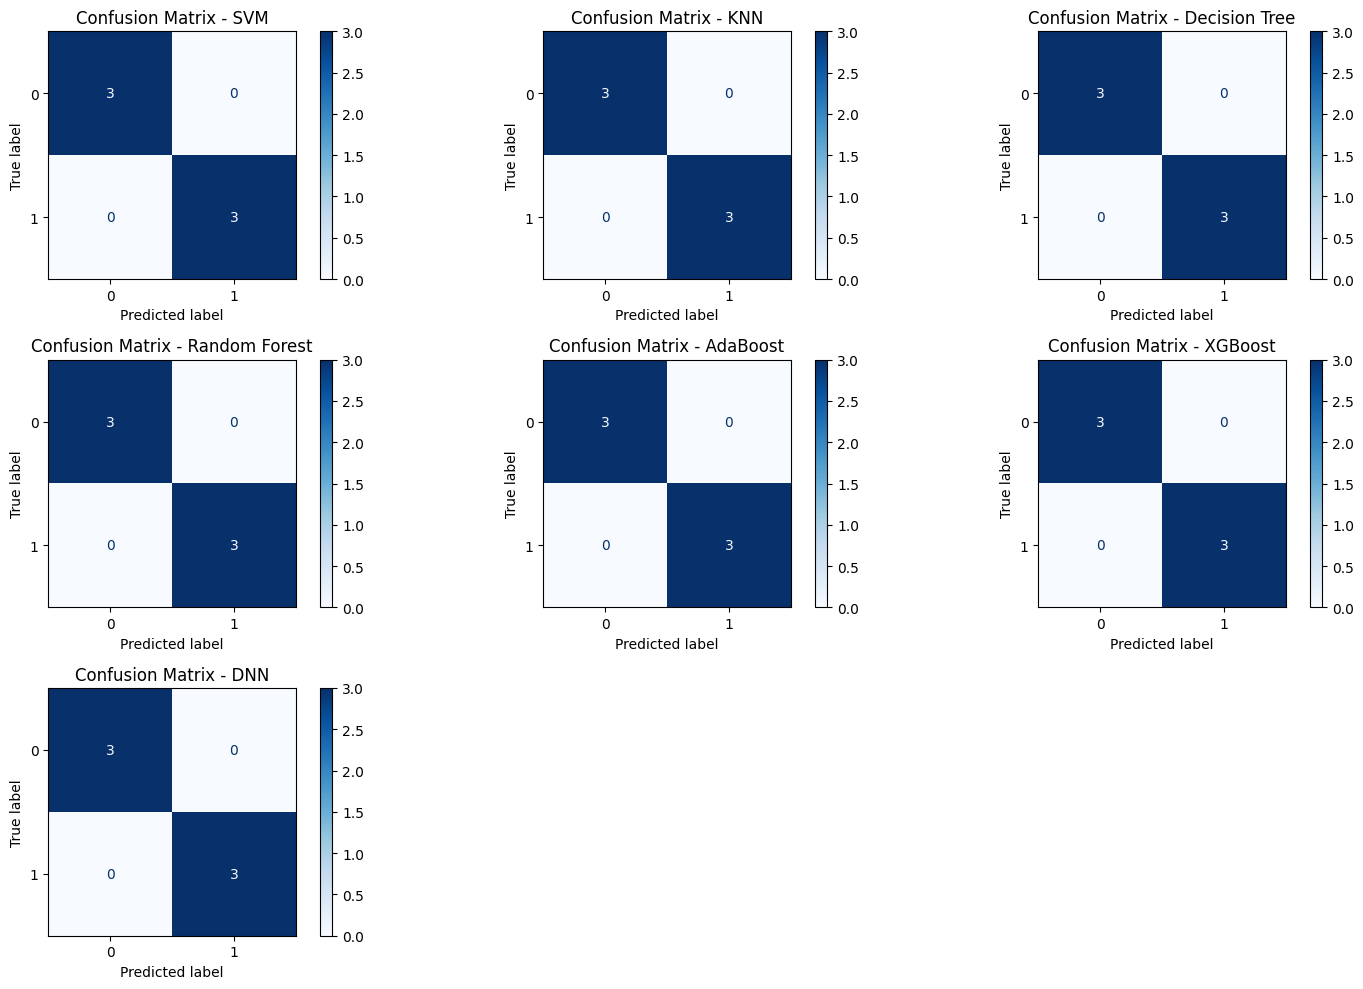

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dictionary to hold all predictions for easy access
predictions_dict = {
    'SVM': y_pred_svm,
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'AdaBoost': y_pred_ada,
    'XGBoost': y_pred_xgb,
    'DNN': y_pred_dnn.flatten() # Flatten DNN predictions if they are 2D
}

plt.figure(figsize=(15, 10)) # Adjust figure size for all plots

for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # Assuming binary classification (0 or 1)

    plt.subplot(3, 3, i + 1) # Create subplots (3 rows, 3 columns)
    disp.plot(ax=plt.gca(), cmap='Blues', values_format='d') # Use current axes
    plt.title(f'Confusion Matrix - {model_name}')

plt.tight_layout()
plt.show()